# Installing the libraries that I will be using

In [1]:
!pip install numpy

In [3]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 71.1 MB/s eta 0:00:01
   -------------------------- ------------- 26.7/40.2 MB 116.2 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 116.9 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 82.5 MB/s  0:00:00


In [4]:
!pip install matplotlib

In [5]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   -- ------------------------------------ 21.8/351.2 MB 117.5 MB/s eta 0:00:03
   ----- --------------------------------- 45.4/351.2 MB 113.3 MB/s eta 0:00:03
   ------- ------------------------------- 66.8/351.2 MB 110.9 MB/s eta 0:00:03
   --------- ----------------------------- 87.6/351.2 MB 107.6 MB/s eta 0:00:03
   ------------ ------------------------- 112.2/351.2 MB 108.4 MB/s eta 0:00:03
   -------------- ----------------------- 136.3/351.2 MB 109.0 MB/s eta 0:00:02
   ----------------- -------------------- 159.9/351.2 MB 109.1 MB/s eta 0:00:02
   ------------------- ------------------ 180.1/351.2 MB 107.0 MB/s eta 0:00:02
   --------------------- ---------------- 200.8/351.2 MB 105.6 MB/s eta 0:00:02
   ----------------------- -------------- 220.7/351.2 MB 104.9 MB/s eta 0:00:02
   ------------------------ ------------- 225.4/351.2 MB 105.1 MB/s eta 0:00:02
   --------------------------- ----------- 243.3/

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [6]:
!pip install nibabel

   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ---------------------------------------- 3.3/3.3 MB 60.9 MB/s  0:00:00


# Visualizing only one picture on the Dataset

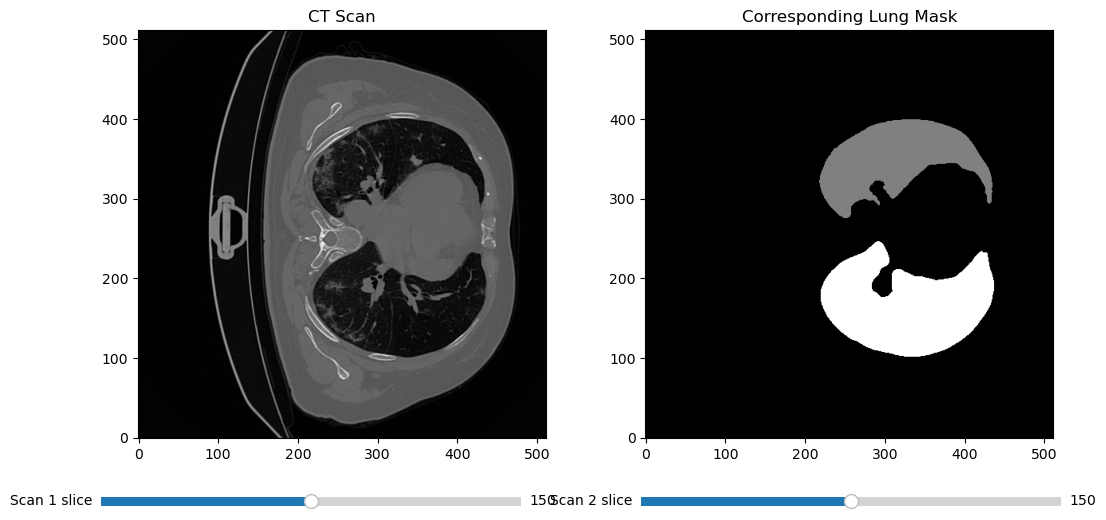

In [11]:
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# Load both scans
img1 = nib.load("ct_scans\coronacases_org_001.nii")
img2 = nib.load("lung_mask\coronacases_001.nii")
data1 = img1.get_fdata()
data2 = img2.get_fdata()

mid1 = data1.shape[2] // 2
mid2 = data2.shape[2] // 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(bottom=0.2)

im1 = ax1.imshow(data1[:, :, mid1], cmap="gray", origin="lower")
ax1.set_title("CT Scan")

im2 = ax2.imshow(data2[:, :, mid2], cmap="gray", origin="lower")
ax2.set_title("Corresponding Lung Mask")

# Slider for scan 1
ax_s1 = plt.axes([0.1, 0.08, 0.35, 0.03])
slider1 = Slider(ax_s1, "Scan 1 slice", 0, data1.shape[2] - 1, valinit=mid1, valstep=1)

# Slider for scan 2
ax_s2 = plt.axes([0.55, 0.08, 0.35, 0.03])
slider2 = Slider(ax_s2, "Scan 2 slice", 0, data2.shape[2] - 1, valinit=mid2, valstep=1)

def update1(val):
    im1.set_data(data1[:, :, int(slider1.val)])
    im1.set_clim(vmin=data1.min(), vmax=data1.max())
    fig.canvas.draw_idle()

def update2(val):
    im2.set_data(data2[:, :, int(slider2.val)])
    im2.set_clim(vmin=data2.min(), vmax=data2.max())
    fig.canvas.draw_idle()

slider1.on_changed(update1)
slider2.on_changed(update2)

plt.show()

In [12]:
# =========================
# 1. Import libraries
# =========================

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import tensorflow as tf

from skimage.transform import resize
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [13]:
# =========================
# 2. Set paths
# =========================

IMAGE_DIR = "ct_scans"   # folder containing CT lung images
MASK_DIR = "lung_mask"     # folder containing lung masks

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 25

# Load .nii images and masks

In [15]:
def load_nii(path):
    nii_file = nib.load(path)
    data = nii_file.get_fdata()
    return data

# Normalizing the image

In [16]:
def normalize_image(image):
    image = image.astype(np.float32)
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val == 0:
        return image

    return (image - min_val) / (max_val - min_val)

In [17]:
def load_data_nii(image_dir, mask_dir):
    images = []
    masks = []

    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".nii") or f.endswith(".nii.gz")])
    mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith(".nii") or f.endswith(".nii.gz")])

    print("Number of image files:", len(image_files))
    print("Number of mask files:", len(mask_files))

    for img_name, mask_name in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, mask_name)

        image_volume = load_nii(img_path)
        mask_volume = load_nii(mask_path)

        print("Loading:", img_name, image_volume.shape)

        if image_volume.shape != mask_volume.shape:
            print("Shape mismatch:", img_name, mask_name)
            continue

        for slice_idx in range(image_volume.shape[2]):
            image_slice = image_volume[:, :, slice_idx]
            mask_slice = mask_volume[:, :, slice_idx]

            image_slice = resize(
                image_slice,
                (IMG_SIZE, IMG_SIZE),
                preserve_range=True,
                anti_aliasing=True
            )

            mask_slice = resize(
                mask_slice,
                (IMG_SIZE, IMG_SIZE),
                preserve_range=True,
                anti_aliasing=False
            )

            image_slice = normalize_image(image_slice)
            mask_slice = (mask_slice > 0.5).astype(np.float32)

            images.append(image_slice)
            masks.append(mask_slice)

    images = np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    masks = np.array(masks).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

    return images, masks


X, y = load_data_nii(IMAGE_DIR, MASK_DIR)

print("Images shape:", X.shape)
print("Masks shape:", y.shape)

Number of image files: 20
Number of mask files: 20
Loading: coronacases_org_001.nii (512, 512, 301)
Loading: coronacases_org_002.nii (512, 512, 200)
Loading: coronacases_org_003.nii (512, 512, 200)
Loading: coronacases_org_004.nii (512, 512, 270)
Loading: coronacases_org_005.nii (512, 512, 290)
Loading: coronacases_org_006.nii (512, 512, 213)
Loading: coronacases_org_007.nii (512, 512, 249)
Loading: coronacases_org_008.nii (512, 512, 301)
Loading: coronacases_org_009.nii (512, 512, 256)
Loading: coronacases_org_010.nii (512, 512, 301)
Loading: radiopaedia_org_covid-19-pneumonia-10_85902_1-dcm.nii (630, 630, 39)
Loading: radiopaedia_org_covid-19-pneumonia-10_85902_3-dcm.nii (630, 630, 418)
Loading: radiopaedia_org_covid-19-pneumonia-14_85914_0-dcm.nii (630, 401, 110)
Loading: radiopaedia_org_covid-19-pneumonia-27_86410_0-dcm.nii (630, 630, 66)
Loading: radiopaedia_org_covid-19-pneumonia-29_86490_1-dcm.nii (630, 630, 42)
Loading: radiopaedia_org_covid-19-pneumonia-29_86491_1-dcm.nii (630

# Train-validation split

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)

Training images: (2816, 256, 256, 1)
Validation images: (704, 256, 256, 1)


# Dice coefficient and loss

In [19]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    total = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    return (2.0 * intersection + smooth) / (total + smooth)


def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# Build U-Net model

In [20]:
def conv_block(inputs, filters):
    x = Conv2D(filters, 3, activation="relu", padding="same")(inputs)
    x = Conv2D(filters, 3, activation="relu", padding="same")(x)
    return x


def build_unet(input_shape=(256, 256, 1)):
    inputs = Input(input_shape)

    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 512)
    p4 = MaxPooling2D((2, 2))(c4)

    bottleneck = conv_block(p4, 1024)

    u1 = Conv2DTranspose(512, 2, strides=2, padding="same")(bottleneck)
    u1 = Concatenate()([u1, c4])
    c5 = conv_block(u1, 512)

    u2 = Conv2DTranspose(256, 2, strides=2, padding="same")(c5)
    u2 = Concatenate()([u2, c3])
    c6 = conv_block(u2, 256)

    u3 = Conv2DTranspose(128, 2, strides=2, padding="same")(c6)
    u3 = Concatenate()([u3, c2])
    c7 = conv_block(u3, 128)

    u4 = Conv2DTranspose(64, 2, strides=2, padding="same")(c7)
    u4 = Concatenate()([u4, c1])
    c8 = conv_block(u4, 64)

    outputs = Conv2D(1, 1, activation="sigmoid")(c8)

    model = Model(inputs, outputs)
    return model


model = build_unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

# Compile model

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=["accuracy", dice_coefficient]
)

# Train model

In [ ]:
checkpoint = ModelCheckpoint(
    "best_lung_segmentation_model.keras",
    monitor="val_dice_coefficient",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
223/352 ━━━━━━━━━━━━━━━━━━━━ 26:40 12s/step - accuracy: 0.9055 - dice_coefficient: 0.2946 - loss: 1.0746

# Show prediction

In [ ]:
def show_prediction(index):
    image = X_val[index]
    true_mask = y_val[index]

    pred_mask = model.predict(np.expand_dims(image, axis=0))[0]
    pred_mask = (pred_mask > 0.5).astype(np.float32)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title("CT Slice")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("True Lung Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Predicted Lung Mask")
    plt.axis("off")

    plt.show()


show_prediction(0)